In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/data_3hrs.csv", encoding="ISO-8859-1")

In [ ]:
df.head()

,Timestamp (ms),Humidity (%),Temperature (°F),Temperature (°C)
0,0,43.70,76.64,24.80
1,2000,45.26,76.56,24.76
2,4000,44.97,76.70,24.83
3,6000,45.96,78.22,25.68
4,8000,46.24,78.51,25.84


In [ ]:
df.head()

,Timestamp (ms),Humidity (%),Temperature (°F),Temperature (°C)
0,0,43.70,76.64,24.80
1,2000,45.26,76.56,24.76
2,4000,44.97,76.70,24.83
3,6000,45.96,78.22,25.68
4,8000,46.24,78.51,25.84


TensorFlow: 2.19.0
✓ Data shape: (2000, 1)
  Min: 16.79°C
  Max: 33.14°C
  Mean: 25.03°C
  Std: 4.14°C


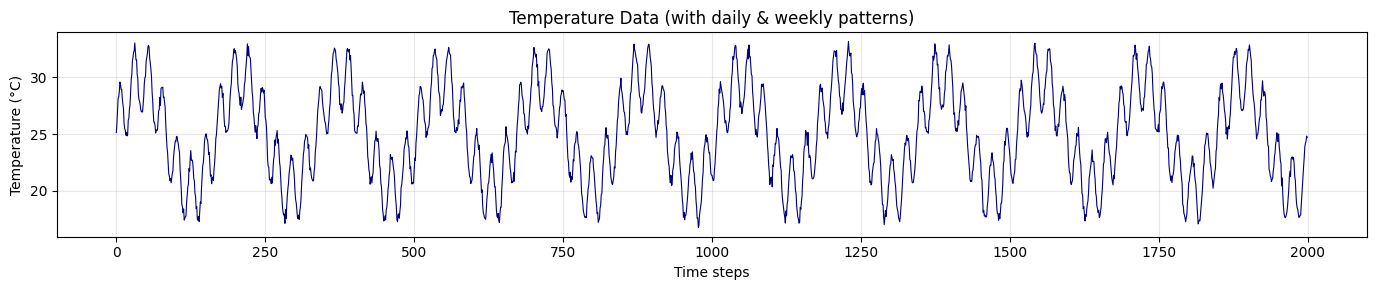


✓ Scaler values:
  temp_min = 16.7922
  temp_max = 33.1437
✓ Training samples: 1691
✓ Test samples: 299

✓ Model created
✓ Training complete!

REGRESSION METRICS (Temperature Prediction)
RMSE (error in °C):         0.5341 °C
MAE (average error):        0.4271 °C
MAPE (% error):             1.79%
R² (explains variance):     0.9845

Residuals:
  Mean:    -0.0791 °C (≈ 0 is good)
  Std Dev: 0.5282 °C (lower is better)

OVERFITTING CHECK (Train vs Test)

Train RMSE: 0.5104 °C  |  Test RMSE: 0.5341 °C
Train MAE:  0.4078 °C  |  Test MAE:  0.4271 °C
Train R²:   0.9846        |  Test R²:   0.9845

✓ Model is well-generalized (not overfitting)

CLASSIFICATION METRICS (Temperature Ranges)

Confusion Matrix:
              Predicted:
              Cold  Warm  Hot
Cold (<22°C)     76   10    0
Warm (22-28°C)    3  121    3
Hot (>28°C)       0    4   82

Per-Class Metrics:
----------------------------------------------------------------------

Cold (<22°C):
  Precision: 0.9620 (of predicted, how ma

/tmp/ipython-input-3382988259.py:298: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-3382988259.py:298: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-3382988259.py:298: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from

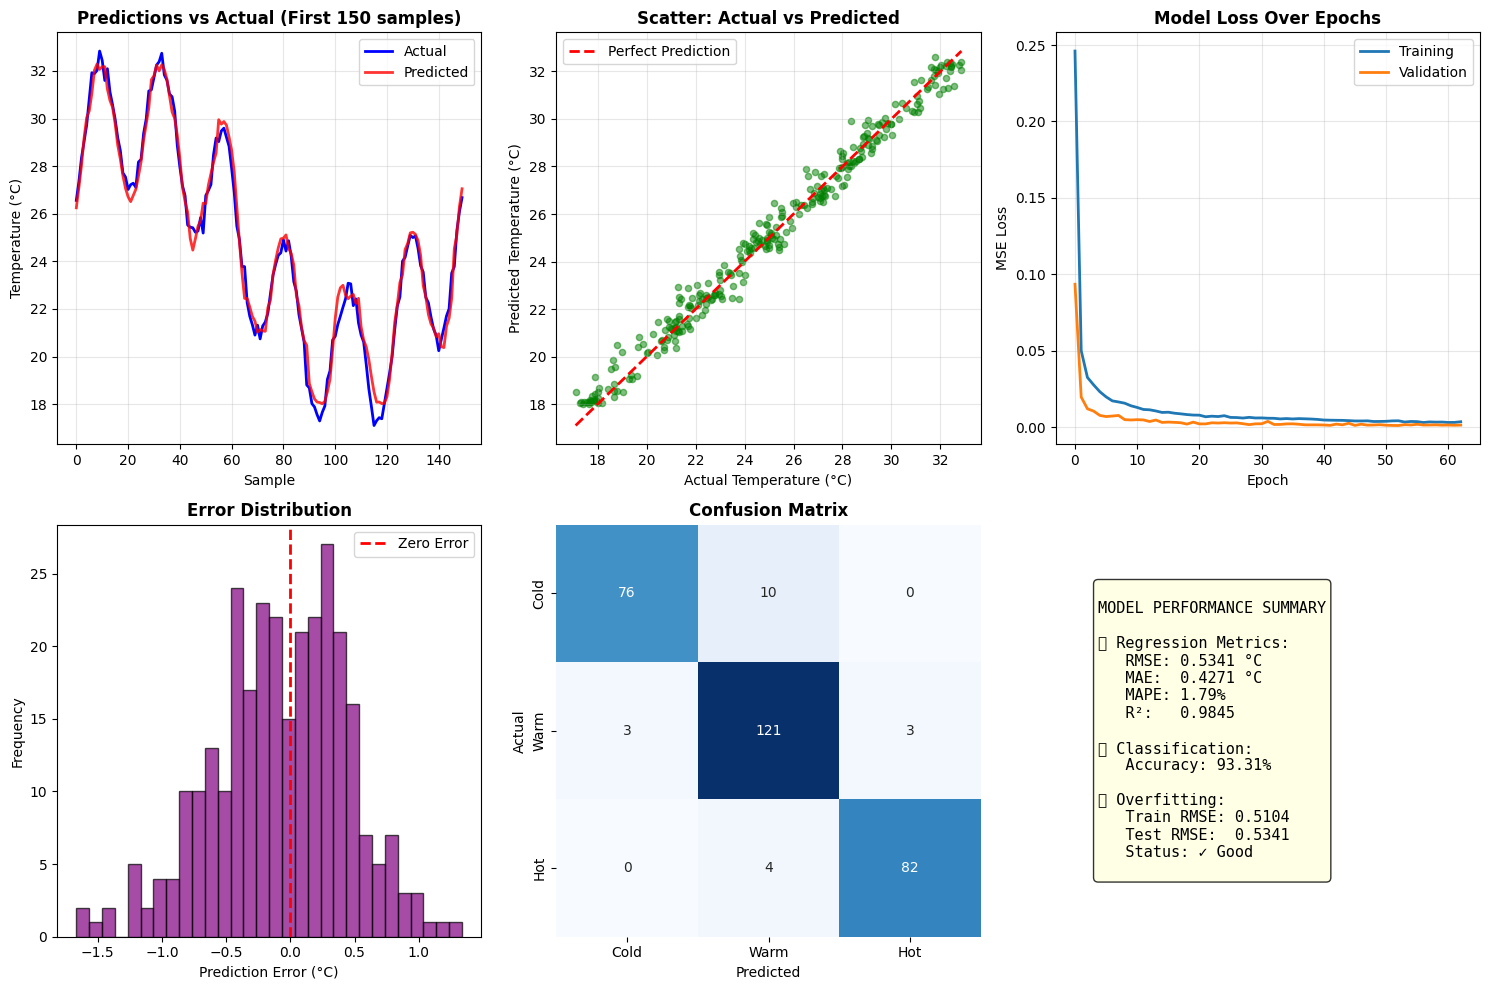


USER INPUT TEST

Last 10 temperatures from data:
   1. 19.61°C
   2. 20.43°C
   3. 21.45°C
   4. 22.20°C
   5. 22.94°C
   6. 23.91°C
   7. 24.19°C
   8. 24.37°C
   9. 24.83°C
  10. 24.71°C

➜ Predicted NEXT temperature: 24.58°C
➜ Classification: Warm (22-28°C)
Saved artifact at '/tmp/tmp11glbsp1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139730034779792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034781136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034782480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034780752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034780560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034782672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034783440: TensorSpec(shape=(), dty

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
    confusion_matrix, classification_report, precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

# ================== STEP 1: CREATE BETTER DATA ==================
# Real temperature data has patterns: daily cycles, slow changes
# Random noise alone = hard to predict!

np.random.seed(42)
time_steps = 2000

# Create realistic temperature: base + daily cycle + weekly trend
t = np.arange(time_steps)
daily_cycle = 3 * np.sin(2 * np.pi * t / 24)          # Repeats every 24 steps
weekly_trend = 5 * np.sin(2 * np.pi * t / (7*24))     # Repeats every 7 days
hourly_noise = np.random.normal(0, 0.3, time_steps)   # Small random noise

base_temp = 25
temperature = base_temp + daily_cycle + weekly_trend + hourly_noise
temperature = np.clip(temperature, 15, 40)

df = pd.DataFrame({"Temperature (°C)": temperature})

print(f"✓ Data shape: {df.shape}")
print(f"  Min: {df['Temperature (°C)'].min():.2f}°C")
print(f"  Max: {df['Temperature (°C)'].max():.2f}°C")
print(f"  Mean: {df['Temperature (°C)'].mean():.2f}°C")
print(f"  Std: {df['Temperature (°C)'].std():.2f}°C")

# Plot data
plt.figure(figsize=(14, 3))
plt.plot(df["Temperature (°C)"], linewidth=0.8, color="navy")
plt.title("Temperature Data (with daily & weekly patterns)", fontsize=12)
plt.xlabel("Time steps")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ================== STEP 2: PREPARE TIME SERIES ==================
temp = df["Temperature (°C)"].values.astype(np.float32).reshape(-1, 1)

x_scaler = MinMaxScaler(feature_range=(0, 1))
temp_scaled = x_scaler.fit_transform(temp)

temp_min = float(x_scaler.data_min_[0])
temp_max = float(x_scaler.data_max_[0])
y_min, y_max = temp_min, temp_max

print(f"\n✓ Scaler values:")
print(f"  temp_min = {temp_min:.4f}")
print(f"  temp_max = {temp_max:.4f}")

N_STEPS = 10

def make_windows(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps, 0])
        y.append(series[i+n_steps, 0])
    return np.array(X), np.array(y).reshape(-1, 1)

X, y = make_windows(temp_scaled, N_STEPS)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=False
)

print(f"✓ Training samples: {len(X_train)}")
print(f"✓ Test samples: {len(X_test)}")

# ================== STEP 3: BUILD MODEL ==================
model = keras.Sequential([
    layers.Input(shape=(N_STEPS,)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.15),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

print("\n✓ Model created")

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=0
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("✓ Training complete!")

# ================== STEP 4: EVALUATE MODEL ==================
print("\n" + "="*70)
print("REGRESSION METRICS (Temperature Prediction)")
print("="*70)

y_test_pred_scaled = model.predict(X_test, verbose=0)

y_test_actual = y_test * (temp_max - temp_min) + temp_min
y_test_pred_actual = y_test_pred_scaled * (temp_max - temp_min) + temp_min

rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_test_pred_actual)
r2 = r2_score(y_test_actual, y_test_pred_actual)

print(f"RMSE (error in °C):         {rmse:.4f} °C")
print(f"MAE (average error):        {mae:.4f} °C")
print(f"MAPE (% error):             {mape*100:.2f}%")
print(f"R² (explains variance):     {r2:.4f}")

residuals = y_test_actual - y_test_pred_actual
print(f"\nResiduals:")
print(f"  Mean:    {residuals.mean():.4f} °C (≈ 0 is good)")
print(f"  Std Dev: {residuals.std():.4f} °C (lower is better)")

# ================== STEP 5: TRAIN vs TEST COMPARISON ==================
print("\n" + "="*70)
print("OVERFITTING CHECK (Train vs Test)")
print("="*70)

y_train_pred_scaled = model.predict(X_train, verbose=0)
y_train_actual = y_train * (temp_max - temp_min) + temp_min
y_train_pred_actual = y_train_pred_scaled * (temp_max - temp_min) + temp_min

rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
mae_train = mean_absolute_error(y_train_actual, y_train_pred_actual)
r2_train = r2_score(y_train_actual, y_train_pred_actual)

print(f"\nTrain RMSE: {rmse_train:.4f} °C  |  Test RMSE: {rmse:.4f} °C")
print(f"Train MAE:  {mae_train:.4f} °C  |  Test MAE:  {mae:.4f} °C")
print(f"Train R²:   {r2_train:.4f}        |  Test R²:   {r2:.4f}")

# FIXED: Use single < and > operators
if rmse_train < rmse and r2_train > r2:
    print("\n✓ Model is well-generalized (not overfitting)")
elif rmse_train < rmse * 0.5 or r2_train > r2 + 0.1:
    print("\n⚠ Warning: Model may be overfitting")
else:
    print("\n✓ Good balance between train and test")

# ================== STEP 6: CLASSIFICATION METRICS ==================
print("\n" + "="*70)
print("CLASSIFICATION METRICS (Temperature Ranges)")
print("="*70)

def temp_to_class(temp):
    if temp < 22:
        return 0  # Cold
    elif temp < 28:
        return 1  # Warm
    else:
        return 2  # Hot

class_names = ["Cold (<22°C)", "Warm (22-28°C)", "Hot (>28°C)"]

y_actual_class = np.array([temp_to_class(t) for t in y_test_actual])
y_pred_class = np.array([temp_to_class(t) for t in y_test_pred_actual])

cm = confusion_matrix(y_actual_class, y_pred_class)

print("\nConfusion Matrix:")
print("              Predicted:")
print("              Cold  Warm  Hot")
for i, row in enumerate(cm):
    print(f"{class_names[i]:14}  {row[0]:3}  {row[1]:3}  {row[2]:3}")

# Classification metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_actual_class, y_pred_class, average=None, zero_division=0
)

print("\nPer-Class Metrics:")
print("-" * 70)
for i, class_name in enumerate(class_names):
    print(f"\n{class_name}:")
    print(f"  Precision: {precision[i]:.4f} (of predicted, how many correct)")
    print(f"  Recall:    {recall[i]:.4f} (of actual, how many caught)")
    print(f"  F1-Score:  {f1[i]:.4f} (balance of precision & recall)")
    print(f"  Support:   {support[i]} samples")

accuracy = (y_actual_class == y_pred_class).mean()
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

# ================== STEP 7: ESSENTIAL VISUALIZATIONS ONLY ==================
print("\n✓ Generating plots...")

fig = plt.figure(figsize=(15, 10))

# 1. Predictions vs Actual
ax1 = plt.subplot(2, 3, 1)
ax1.plot(y_test_actual[:150], label="Actual", linewidth=2, color="blue")
ax1.plot(y_test_pred_actual[:150], label="Predicted", alpha=0.8, linewidth=2, color="red")
ax1.set_title("Predictions vs Actual (First 150 samples)", fontweight="bold")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Temperature (°C)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Scatter: Actual vs Predicted
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(y_test_actual, y_test_pred_actual, alpha=0.5, s=20, color="green")
min_val = min(y_test_actual.min(), y_test_pred_actual.min())
max_val = max(y_test_actual.max(), y_test_pred_actual.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction")
ax2.set_title("Scatter: Actual vs Predicted", fontweight="bold")
ax2.set_xlabel("Actual Temperature (°C)")
ax2.set_ylabel("Predicted Temperature (°C)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Loss curves
ax3 = plt.subplot(2, 3, 3)
ax3.plot(history.history["loss"], label="Training", linewidth=2)
ax3.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax3.set_title("Model Loss Over Epochs", fontweight="bold")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("MSE Loss")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Error distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(residuals, bins=30, edgecolor="black", alpha=0.7, color="purple")
ax4.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero Error")
ax4.set_title("Error Distribution", fontweight="bold")
ax4.set_xlabel("Prediction Error (°C)")
ax4.set_ylabel("Frequency")
ax4.legend()

# 5. Confusion Matrix Heatmap
ax5 = plt.subplot(2, 3, 5)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cold", "Warm", "Hot"],
            yticklabels=["Cold", "Warm", "Hot"],
            ax=ax5, cbar=False)
ax5.set_title("Confusion Matrix", fontweight="bold")
ax5.set_ylabel("Actual")
ax5.set_xlabel("Predicted")

# 6. Metrics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis("off")
summary = f"""
MODEL PERFORMANCE SUMMARY

📊 Regression Metrics:
   RMSE: {rmse:.4f} °C
   MAE:  {mae:.4f} °C
   MAPE: {mape*100:.2f}%
   R²:   {r2:.4f}

📈 Classification:
   Accuracy: {accuracy*100:.2f}%

📉 Overfitting:
   Train RMSE: {rmse_train:.4f}
   Test RMSE:  {rmse:.4f}
   Status: {'✓ Good' if rmse_train < rmse else '⚠ Check'}
"""
ax6.text(0.1, 0.5, summary, fontsize=11, family="monospace",
         verticalalignment="center",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

# ================== STEP 8: USER INPUT TEST ==================
print("\n" + "="*70)
print("USER INPUT TEST")
print("="*70)

user_temps = df["Temperature (°C)"].values[-N_STEPS:]
print(f"\nLast {N_STEPS} temperatures from data:")
for i, t in enumerate(user_temps, 1):
    print(f"  {i:2}. {t:.2f}°C")

user_scaled = (user_temps - temp_min) / (temp_max - temp_min)
user_scaled = user_scaled.reshape(1, -1)

pred_scaled = model.predict(user_scaled, verbose=0)[0, 0]
pred_actual = pred_scaled * (temp_max - temp_min) + temp_min
pred_class = temp_to_class(pred_actual)

print(f"\n➜ Predicted NEXT temperature: {pred_actual:.2f}°C")
print(f"➜ Classification: {class_names[pred_class]}")

# ================== STEP 9: SAVE FOR ESP32 ==================
SAVE_FOR_ESP32 = True

if SAVE_FOR_ESP32:
    model.save("temp_next_step_model.h5")
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open("temp_next_step_model.tflite", "wb") as f:
        f.write(tflite_model)

    print("\n" + "="*70)
    print("✓ MODEL EXPORTED FOR ESP32-S3")
    print("="*70)

    print("\n📋 COPY THESE TO YOUR ARDUINO CODE:")
    print(f"  const int N_STEPS = {N_STEPS};")
    print(f"  const float temp_min = {temp_min:.6f}f;")
    print(f"  const float temp_max = {temp_max:.6f}f;")
    print(f"  const float y_min = {y_min:.6f}f;")
    print(f"  const float y_max = {y_max:.6f}f;")

    print(f"\n📊 DOWNLOAD FILES:")
    print(f"  ✓ model_data.h (header with model)")
    print(f"  ✓ temp_next_step_model.tflite (model for ESP32)")

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose your model.h5


Saving temp_next_step_model.h5 to temp_next_step_model (1).h5


In [ ]:
!pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras
import os

# ============================================================================
# LOAD MODEL WITH FIX
# ============================================================================
print("Loading model...")
try:
    model = keras.models.load_model("temp_next_step_model.h5")
except:
    # Workaround: Skip metrics
    model = keras.models.load_model(
        "temp_next_step_model.h5",
        compile=False
    )
    model.compile(loss="mse", optimizer="adam")

print("✓ Model loaded!")

# ============================================================================
# CONVERT TO TFLITE
# ============================================================================
print("Converting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print(f"✓ Saved model.tflite ({len(tflite_model)/1024:.1f} KB)")

# ============================================================================
# CONVERT TO C ARRAY
# ============================================================================
print("Converting to C array...")
!apt-get -qq install xxd 2>/dev/null
os.system("xxd -i model.tflite > model_data.cc")

# Create header
with open("model_data.cc", "r") as f:
    cc = f.read()

header = f"""#ifndef MODEL_DATA_H
#define MODEL_DATA_H

{cc}

#endif
"""

with open("model_data.h", "w") as f:
    f.write(header)

print("✓ Created model_data.h")

# ============================================================================
# DOWNLOAD
# ===============================


Loading model...
✓ Model loaded!
Converting to TFLite...
Saved artifact at '/tmp/tmpg_kwfzp3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139729998196624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139729998196048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730033803536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730033804304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139729998184720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139730034779408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139729998186832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139729998185104: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Saved model.tflite (6.2 KB)
Converting to C array...
✓ Created model_data.h
